# Passo 14 — Visualizações e EDA
**Dataset:** Oscar AMPAS — Winner Demographics (1927–2014)  
**Fonte:** Banco PostgreSQL (container oscar-db)

In [1]:
import sys
!'{sys.executable}' -m pip install psycopg2-binary pandas matplotlib -q

A sintaxe do nome do arquivo, do nome do diret�rio ou do r�tulo do volume est� incorreta.


In [2]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import os

SQL_ROOT = Path(os.path.abspath('')).parent / 'Etapa4_EDA'

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DB = dict(host='localhost', port=5432, dbname='oscar', user='postgres', password='brasil123')

def query(sql):
    with psycopg2.connect(**DB) as conn:
        return pd.read_sql(sql, conn)

print('Conexão OK')

def get_query(i: int):
    path = SQL_ROOT / f'p{i}.sql'
    with open(path) as file:
        query_str = file.read()
    return query_str



Conexão OK


## P1 — Filmes que varreram mais categorias

C:\Users\muniz\AppData\Local\Temp\ipykernel_1148\367609974.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


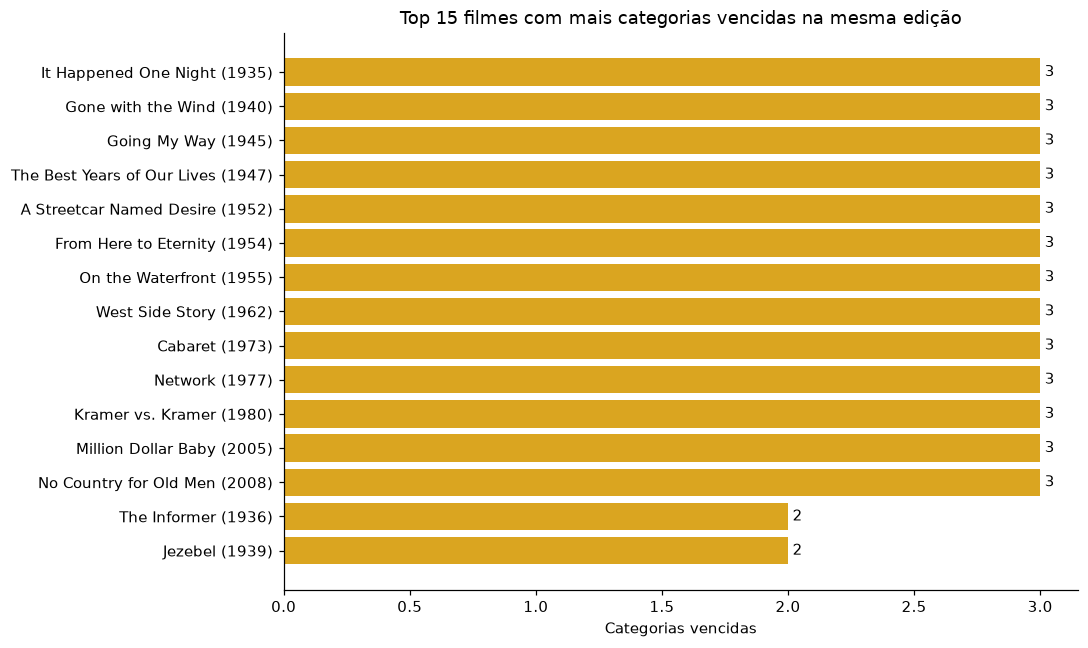

In [3]:

query_str = get_query(1)
df1 = query(query_str)

df1['label'] = df1['titulo'] + ' (' + df1['ano'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df1['label'], df1['categorias_vencidas'], color='goldenrod')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Categorias vencidas')
ax.set_title('Top 15 filmes com mais categorias vencidas na mesma edição')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('grafico_p1_filmes_multivencedores.png', dpi=110)
plt.show()

## P2 — Evolução da diversidade étnica por década

C:\Users\muniz\AppData\Local\Temp\ipykernel_1148\367609974.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


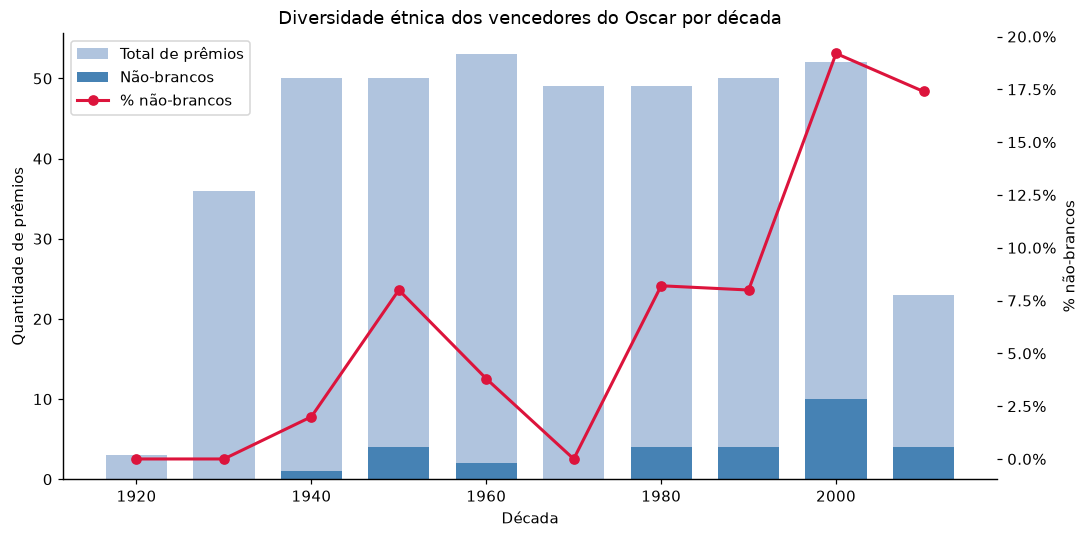

In [4]:
query_str = get_query(2)
df2 = query(query_str)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(df2['decada'], df2['total'],     width=7, color='lightsteelblue', label='Total de prêmios')
ax1.bar(df2['decada'], df2['nao_brancos'], width=7, color='steelblue',   label='Não-brancos')
ax2.plot(df2['decada'], df2['pct'], color='crimson', marker='o', linewidth=2, label='% não-brancos')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

ax1.set_xlabel('Década')
ax1.set_ylabel('Quantidade de prêmios')
ax2.set_ylabel('% não-brancos')
ax1.set_title('Diversidade étnica dos vencedores do Oscar por década')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('grafico_p2_diversidade_decada.png', dpi=110)
plt.show()

## P3 — Idade dos vencedores por categoria

C:\Users\muniz\AppData\Local\Temp\ipykernel_1148\367609974.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


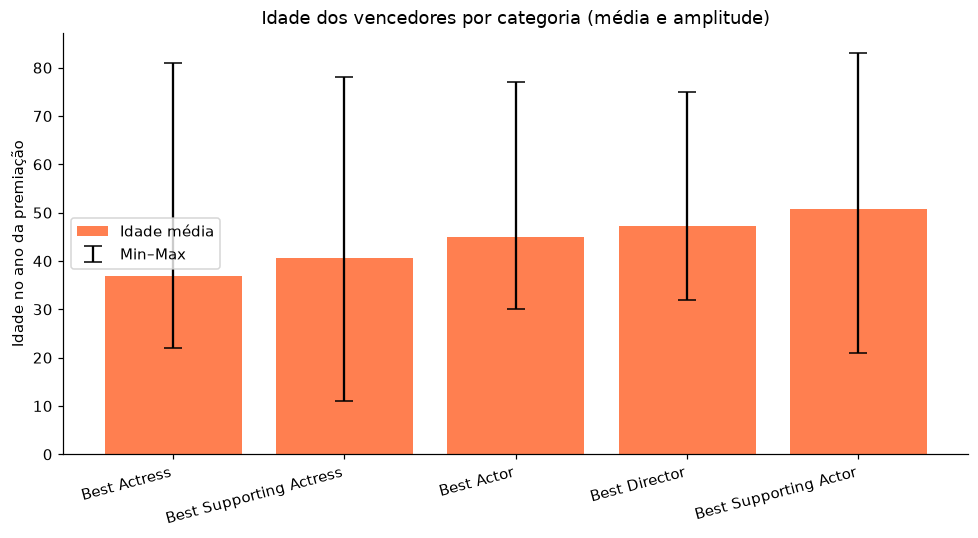

,categoria,idade_media,mais_jovem,mais_velho
0,Best Actress,36.9,22,81
1,Best Supporting Actress,40.6,11,78
2,Best Actor,45.0,30,77
3,Best Director,47.3,32,75
4,Best Supporting Actor,50.7,21,83


In [5]:
query_str = get_query(3)
df3 = query(query_str)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(df3))
ax.bar(x, df3['idade_media'], color='coral', label='Idade média')
ax.errorbar(x,
            df3['idade_media'],
            yerr=[df3['idade_media'] - df3['mais_jovem'],
                  df3['mais_velho']  - df3['idade_media']],
            fmt='none', color='black', capsize=6, linewidth=1.5, label='Min–Max')

ax.set_xticks(x)
ax.set_xticklabels(df3['categoria'], rotation=15, ha='right')
ax.set_ylabel('Idade no ano da premiação')
ax.set_title('Idade dos vencedores por categoria (média e amplitude)')
ax.legend()
plt.tight_layout()
plt.savefig('grafico_p3_idade_categoria.png', dpi=110)
plt.show()
df3

## P4 — Maior intervalo entre vitórias consecutivas

C:\Users\muniz\AppData\Local\Temp\ipykernel_1148\367609974.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


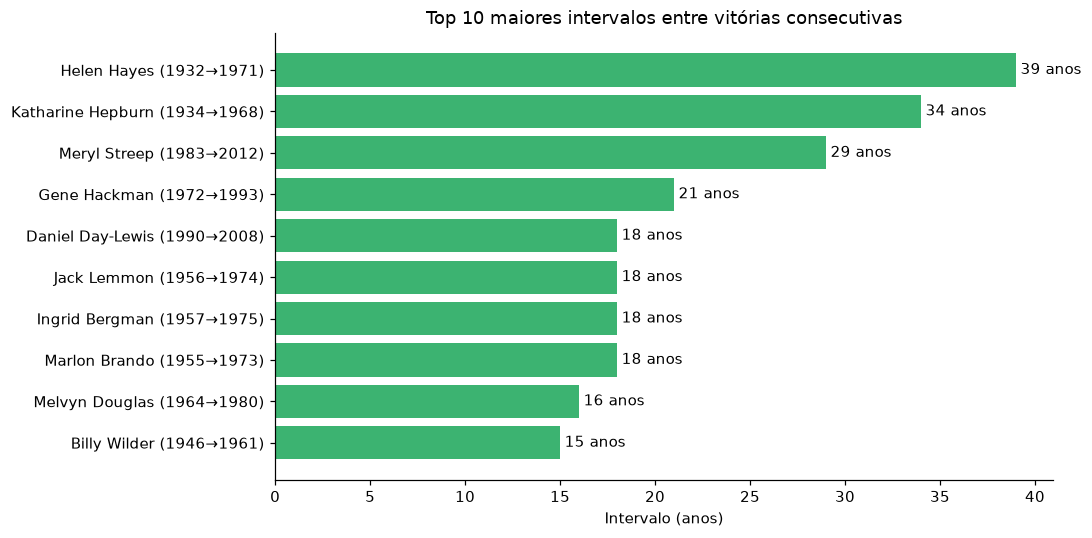

In [6]:
query_str = get_query(4)
df4 = query(query_str)

fig, ax = plt.subplots(figsize=(10, 5))
df4['label'] = df4['nome'] + ' (' + df4['primeiro'].astype(str) + '→' + df4['segundo'].astype(str) + ')'
bars = ax.barh(df4['label'], df4['intervalo'], color='mediumseagreen')
ax.bar_label(bars, fmt='%d anos', padding=3)
ax.set_xlabel('Intervalo (anos)')
ax.set_title('Top 10 maiores intervalos entre vitórias consecutivas')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('grafico_p4_intervalo_vitorias.png', dpi=110)
plt.show()

## P5 — Primeiro vencedor não-branco por categoria

C:\Users\muniz\AppData\Local\Temp\ipykernel_1148\367609974.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


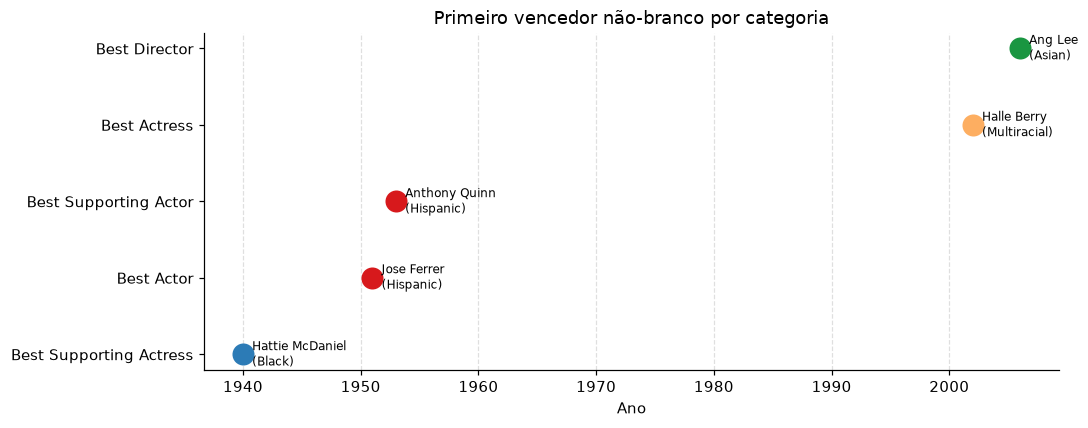

,categoria,vencedor,etnia,ano
0,Best Supporting Actress,Hattie McDaniel,Black,1940
1,Best Actor,Jose Ferrer,Hispanic,1951
2,Best Supporting Actor,Anthony Quinn,Hispanic,1953
3,Best Actress,Halle Berry,Multiracial,2002
4,Best Director,Ang Lee,Asian,2006


In [10]:
query_str = get_query(5)
df5 = query(query_str)

cores = {'Black': '#2c7bb6', 'Hispanic': '#d7191c', 'Asian': '#1a9641', 'Multiracial': '#fdae61'}

fig, ax = plt.subplots(figsize=(10, 4))
for _, row in df5.iterrows():
    cor = cores.get(row['etnia'], 'gray')
    ax.scatter(row['ano'], row['categoria'], color=cor, s=180, zorder=3)
    ax.annotate(f"{row['vencedor']}\n({row['etnia']})",
                xy=(row['ano'], row['categoria']),
                xytext=(6, 0), textcoords='offset points',
                fontsize=8, va='center')

ax.set_xlabel('Ano')
ax.set_title('Primeiro vencedor não-branco por categoria')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico_p5_primeira_vitoria_nao_branca.png', dpi=110)
plt.show()
df5